In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from dataclasses import asdict
from functools import partial
from ciceroscm import input_handler
import pandas as pd
from meteor import MeteorPatternScaling
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter
import warnings
from pandas.errors import SettingWithCopyWarning
warnings.filterwarnings('ignore', category=FutureWarning) 
warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings("ignore", message=".*not in pamset.*")


In [2]:
from meteor import prpatt

In [3]:
from scipy.linalg import pinv

In [4]:
cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")


In [5]:
from meteor import scm_forcer_engine
from ciceroscm import CICEROSCM

Getting a datagetter to get CMIP6 data from the zarrstore for tas and pr

In [6]:
flds = ["tas", "pr"]
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "historical", "ssp245"], flds = flds, dbe=['CMIP','CMIP','CMIP', 'ScenarioMIP'])
# This list now holds all the models with complete data for a single ensemble member for the given experiments and fields
models = data_getter.models
# For the purposes of this notebook we limit the use to looking at two coarse resolution models:
models = ["CanESM5"]

Getting some data that can be used by the forcer engine and ciceroscm

In [7]:
# NBVAL_IGNORE_OUTPUT
#For predictions: 
conc_data = input_handler.read_inputfile(
    os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt")
)
ih = input_handler.InputHandler({})
em_data = ih.read_emissions(os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt"))

Parameter nystart not in pamset. Using default value 1750
Parameter nyend not in pamset. Using default value 2100
Parameter emstart not in pamset. Using default value 1850


In [8]:
em_data_ghg=em_data.copy()
em_data_aer=em_data.copy()

In [9]:
em_data_ghg['SO2']=0
em_data_aer=em_data*0
em_data_aer['SO2']=em_data['SO2']

Making a list of xarray data for the piControl, historical and ssp experiment

In [10]:
data_pi=[None]*len(models)
for i, model in enumerate(models):
    tmp_pi=[None]*len(flds)
    for j, fld in enumerate(flds):
        tmp_pi[j]=data_getter.get_single_var_mod_data_yearmean("piControl", fld, model)
    data_pi[i]=xr.merge(tmp_pi)


In [11]:
data_hist=[None]*len(models)
for i, model in enumerate(models):
    tmp_hist=[None]*len(flds)
    for j, fld in enumerate(flds):
        tmp_hist[j]=data_getter.get_single_var_mod_data_yearmean("historical", fld, model)
    data_hist[i]=xr.merge(tmp_hist)
    data_hist[i]['year']=pd.date_range('1850-01-01', periods=data_hist[i]['year'].shape[0],freq='YS')

In [12]:
pd.date_range('1850-01-01', periods=data_hist[i]['year'].shape[0],freq='YS')

DatetimeIndex(['1850-01-01', '1851-01-01', '1852-01-01', '1853-01-01',
               '1854-01-01', '1855-01-01', '1856-01-01', '1857-01-01',
               '1858-01-01', '1859-01-01',
               ...
               '2005-01-01', '2006-01-01', '2007-01-01', '2008-01-01',
               '2009-01-01', '2010-01-01', '2011-01-01', '2012-01-01',
               '2013-01-01', '2014-01-01'],
              dtype='datetime64[ns]', length=165, freq='YS-JAN')

In [13]:
data_ssp=[None]*len(models)
for i, model in enumerate(models):
    tmp_ssp=[None]*len(flds)
    for j, fld in enumerate(flds):
        tmp_ssp[j]=data_getter.get_single_var_mod_data_yearmean("ssp245", fld, model)
    data_ssp[i]=xr.merge(tmp_ssp)
    data_ssp[i]['year']=pd.date_range('2015-01-01', periods=data_ssp[i]['year'].shape[0],freq='YS')

Making a temporary partial function to prepare training data that can be used to make a pattern. Starting with just base (piControl) and co2x4 (abrupt4xCO2)

In [14]:
train_data=data_getter.make_meteor_training_data

In [15]:
tmp=partial(train_data, model='CanESM5')

In [16]:
data_getter.exps

['piControl', 'abrupt-4xCO2', 'historical', 'ssp245']

In [17]:
local_data={}
exp_list=["base", "co2x4"]
for i, model in enumerate(models):
    local_data[model]={}
    tmp=partial(train_data, model=model)
    for e in exp_list:
      local_data[model][e]=tmp(exp=e)

In [18]:
# NBVAL_IGNORE_OUTPUT
model_basic_pattern = [None] * len(models)
for i, model in enumerate(models):
    # Build pattern 
    model_basic_pattern[i] = MeteorPatternScaling(
        f"cmip6-{model}-basic",
        {"tas": 2, "pr": 2},
        lambda key: local_data[model][key],
        from_file=False,
        exp_list=exp_list,
        )



Parameter nystart not in pamset. Using default value 1750
Parameter nyend not in pamset. Using default value 2100
Parameter emstart not in pamset. Using default value 1850
Parameter conc_run is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter qbmb not in pamset. Using default value 0.0
Parameter qo3 not in pamset. Using default value 0.5
Parameter qdirso2 not in pamset. Using default value -0.36
Parameter qindso2 not in pamset. Using default value -0.97
Parameter qbc not in pamset. Using default value 0.16
Parameter qoc not in pamset. Using default value -0.08
Parameter qh2o_ch4 not in pamset. Using default value 0.091915
Parameter ref_yr not in pamset. Using default value 2010
Parameter beta_f not in pamset. Using default value 0.287
Parameter lifetime_mode is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter lifetime_mode is not used. Please check if yo

11
12
113
114
115
22
141
123
142
11
12
113
114
115
22
141
123
142
Parameters([('t0', <Parameter 't0', value=0.02635348496269896, bounds=[0:100.0]>), ('s0', <Parameter 's0', value=0.3232304921603683, bounds=[-inf:inf]>), ('t1', <Parameter 't1', value=3.687427419493683, bounds=[0:1000.0]>), ('s1', <Parameter 's1', value=-0.33206717172357375, bounds=[-inf:inf]>)])
Parameters([('t0', <Parameter 't0', value=99.9999999975683 +/- 1.23e+03, bounds=[0:100.0]>), ('s0', <Parameter 's0', value=6.09977879607861e-07 +/- 0.00016, bounds=[-inf:inf]>), ('t1', <Parameter 't1', value=999.5393163676133 +/- 8.05e+05, bounds=[0:1000.0]>), ('s1', <Parameter 's1', value=-4.647801352864957e-06 +/- 0.00278, bounds=[-inf:inf]>)])
Parameters([('t0', <Parameter 't0', value=1.2796126830953103 +/- 0.346, bounds=[0:100.0]>), ('s0', <Parameter 's0', value=3.1850164839660646 +/- 0.324, bounds=[-inf:inf]>), ('t1', <Parameter 't1', value=26.103846140131893 +/- 4.27, bounds=[0:1000.0]>), ('s1', <Parameter 's1', value=4.42

GHG only prediction

In [19]:
# NBVAL_IGNORE_OUTPUT
pattern_ghg=[None] * len(models)
for i, model in enumerate(models):
    #sys.exit(4)
    # Predict for ssp
    pattern_ghg[i] = model_basic_pattern[i].predict_from_combined_experiment(
        em_data_ghg, conc_data, ["pr", "tas"]
        )


Parameter nystart must be a number. Using default value 1750
Parameter emstart must be a number. Using default value 1850
Parameter gaspam_data is not used. Please check if you have a typo
Parameter concentrations_data is not used. Please check if you have a typo
Parameter emissions_data is not used. Please check if you have a typo
Parameter nat_ch4_data is not used. Please check if you have a typo
Parameter nat_n2o_data is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter nystart must be a number. Using default value 1750
Parameter emstart must be a number. Using default value 1850
Parameter gaspam_data is not used. Please check if you have a typo
Parameter concentrations_data is not used. Please check if you have a typo
Parameter emissions_data is not used. Please check if you have a typo
Parameter nat_ch4_data is not used. Please check if you have a typo
Parameter nat_n2o_data is not used. Please check if you have a t

11
12
113
114
115
22
141
123
142
base
co2x4
<xarray.DataArray ()> Size: 8B
array(8.94198024e-07)
<xarray.DataArray ()> Size: 8B
array(1.44232722)


All forcing prediction

In [20]:
# NBVAL_IGNORE_OUTPUT
pattern_ssp=[None] * len(models)
for i, model in enumerate(models):
    #sys.exit(4)
    # Predict for ssp
    pattern_ssp[i] = model_basic_pattern[i].predict_from_combined_experiment(
        em_data, conc_data, ["pr", "tas"]
        )


Parameter nystart must be a number. Using default value 1750
Parameter emstart must be a number. Using default value 1850
Parameter gaspam_data is not used. Please check if you have a typo
Parameter concentrations_data is not used. Please check if you have a typo
Parameter emissions_data is not used. Please check if you have a typo
Parameter nat_ch4_data is not used. Please check if you have a typo
Parameter nat_n2o_data is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter nystart must be a number. Using default value 1750
Parameter emstart must be a number. Using default value 1850
Parameter gaspam_data is not used. Please check if you have a typo
Parameter concentrations_data is not used. Please check if you have a typo
Parameter emissions_data is not used. Please check if you have a typo
Parameter nat_ch4_data is not used. Please check if you have a typo
Parameter nat_n2o_data is not used. Please check if you have a t

11
12
113
114
115
22
141
123
142
base
co2x4
<xarray.DataArray ()> Size: 8B
array(6.35886709e-07)
<xarray.DataArray ()> Size: 8B
array(1.04858854)


run CICEROSCM to get all forcing and aerosol only response

In [21]:
def to_df(cscm,kys):
    out=pd.concat([pd.DataFrame(v) for k, v in cscm.results.items()], axis = 1, keys = kys)
    return out

In [22]:
conc_data

,CO2,CH4,N2O,CFC-11,CFC-12,CFC-113,CFC-114,CFC-115,CH3Br,CCl4,...,HFC143a,HFC227ea,HFC23,HFC245fa,HFC32,HFC4310mee,C2F6,C6F14,CF4,SF6
Component,,,,,,,,,,,,,,,,,,,,,
1700,276.746000,706.054021,272.212049,0.000000,0.000000,0.000000,0.00000,0.00000,5.299998,0.025,...,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.00000,0.000000,34.049999,0.0000
1701,276.749995,706.247004,272.243047,0.000000,0.000000,0.000000,0.00000,0.00000,5.299998,0.025,...,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.00000,0.000000,34.049999,0.0000
1702,276.757998,706.375031,272.266047,0.000000,0.000000,0.000000,0.00000,0.00000,5.299998,0.025,...,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.00000,0.000000,34.049999,0.0000
1703,276.757001,706.491002,272.298047,0.000000,0.000000,0.000000,0.00000,0.00000,5.299998,0.025,...,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.00000,0.000000,34.049999,0.0000
1704,276.755000,706.602046,272.331052,0.000000,0.000000,0.000000,0.00000,0.00000,5.299998,0.025,...,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.00000,0.000000,34.049999,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2496,579.768997,997.339930,359.840983,0.015106,2.975109,0.251401,1.05305,3.93032,4.880721,0.000,...,0.263055,0.000179,3.15741,0.0,0.0,0.0,9.59912,0.685107,140.825001,18.1191
2497,579.599996,997.329926,359.825979,0.014794,2.943329,0.248462,1.04701,3.92252,4.880821,0.000,...,0.257128,0.000173,3.14129,0.0,0.0,0.0,9.59816,0.684886,140.822000,18.1134
2498,579.432007,997.319931,359.811981,0.014489,2.911889,0.245556,1.04100,3.91474,4.880931,0.000,...,0.251334,0.000167,3.12525,0.0,0.0,0.0,9.59720,0.684665,140.818998,18.1077


Implement direct CICERO-SCM aerosol temperature prediction

In [23]:
# NBVAL_IGNORE_OUTPUT
tmp=scm_forcer_engine.ScmEngineForPatternScaling()
ccfg=asdict(tmp.cfg)
ccfg['conc_run']=False
ccfg['emissions_data']=em_data
ccfg['concentrations_data']=conc_data
ccfg['emstart']=1850
ccfg['nystart']=1750
ccfg['nyend']=2200
ccfg['nat_ch4_data'] = pd.DataFrame(
                data={"CH4": np.ones(ccfg['nyend'] - ccfg['nystart'] + 1) * 242.09},
                index=np.arange(ccfg['nystart'], ccfg['nyend'] + 1),
            )
ccfg['nat_n2o_data'] = pd.DataFrame(
                data={"N2O": np.ones(ccfg['nyend'] - ccfg['nystart'] + 1) * 11.7027},
                index=np.arange(ccfg['nystart'], ccfg['nyend'] + 1),
            )
out=CICEROSCM(ccfg)
out._run({
            "results_as_dict":True
        },ccfg)
t_all=out.results['dT_glob']

ccfg['emissions_data']=em_data_aer
out_aer=CICEROSCM(ccfg)

out_aer._run({
            "results_as_dict":True
        },ccfg)
t_aer=out_aer.results['dT_glob']



Parameter nystart not in pamset. Using default value 1750
Parameter nyend not in pamset. Using default value 2100
Parameter emstart not in pamset. Using default value 1850
Parameter gaspam_data is not used. Please check if you have a typo
Parameter concentrations_data is not used. Please check if you have a typo
Parameter emissions_data is not used. Please check if you have a typo
Parameter emstart is not used. Please check if you have a typo
Parameter nystart is not used. Please check if you have a typo
Parameter nyend is not used. Please check if you have a typo
Parameter idtm is not used. Please check if you have a typo
Parameter nat_ch4_data is not used. Please check if you have a typo
Parameter nat_n2o_data is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter rlamdo not in pamset. Using default value 15.0
Parameter akapa not in pamset. Using default value 0.66
Parameter cpi not in pamset. Using default value 0.21
Pa

11
12
113
114
115
22
141
123
142


Parameter gaspam_data is not used. Please check if you have a typo
Parameter concentrations_data is not used. Please check if you have a typo
Parameter emissions_data is not used. Please check if you have a typo
Parameter emstart is not used. Please check if you have a typo
Parameter nystart is not used. Please check if you have a typo
Parameter nyend is not used. Please check if you have a typo
Parameter idtm is not used. Please check if you have a typo
Parameter nat_ch4_data is not used. Please check if you have a typo
Parameter nat_n2o_data is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter rlamdo not in pamset. Using default value 15.0
Parameter akapa not in pamset. Using default value 0.66
Parameter cpi not in pamset. Using default value 0.21
Parameter W not in pamset. Using default value 2.2
Parameter beto not in pamset. Using default value 6.9
Parameter threstemp not in pamset. Using default value 7.0
Parameter 

11
12
113
114
115
22
141
123
142


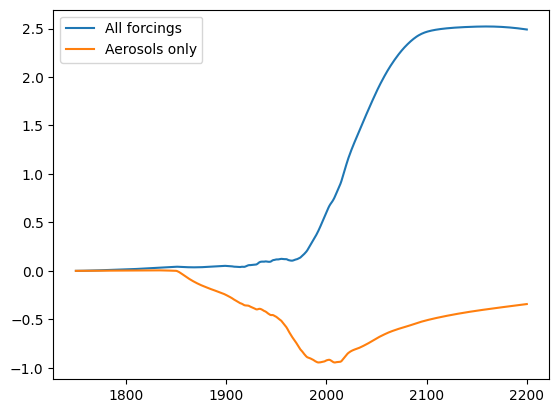

In [24]:
# NBVAL_IGNORE_OUTPUT
plt.plot(out_aer.results['emissions'].index,t_all,label='All forcings')
plt.plot(out_aer.results['emissions'].index,t_aer,label='Aerosols only')
plt.legend()


Aerosol temperautre time series as xarray DataArray

In [25]:
xta=xr.DataArray(data=t_aer[:-100],dims=["time"],coords=dict(time=prpatt.global_mean(pattern_ssp[0]['tas']).time))

Making aerosol patterns from 1970-2010 spatial residual times the scaled timeseries

In [26]:
pattern_aer=len(models)*[None]
for i, model in enumerate(models):
    pattern_aer[i]={}
    for j, fld in enumerate(flds):
        patt_ghg=pattern_ghg[i][fld].sel(time=slice("1970-06-01", "2010-06-10")).mean('time')
        patt_hist=data_hist[i][fld].sel(year=slice("1970-06-01", "2010-06-10")).mean('year')
        patt_base=data_pi[i][fld].mean('year')
        pyrs=pattern_ghg[i][fld].time.dt.year.values
        #mn_aemis=em_data[(em_data.index >= 1990) & (em_data.index <= 2010)]['SO2'].mean()
        mn_aemis=xta.sel(time=slice("1970-06-01", "2010-06-10")).mean()
        apat=((patt_hist-patt_base)-patt_ghg)
        #em_scl=em_data['SO2'][(em_data.index >= min(pyrs)) & (em_data.index <= max(pyrs))].to_xarray().rename({'Component':'time'})
        #em_scl['time']=pattern_ssp[i][fld].time
        em_scl=xta/mn_aemis
        print(apat.mean('lat').mean('lon'))
        pattern_aer[i][fld]=(em_scl*apat)+pattern_ghg[i][fld]

<xarray.DataArray (ens: 1)> Size: 8B
array([-1.42073823])
Coordinates:
  * ens      (ens) int64 8B 1
    height   float64 8B 2.0
<xarray.DataArray (ens: 1)> Size: 8B
array([-1.13327498e-06])
Coordinates:
  * ens      (ens) int64 8B 1
    height   float64 8B 2.0


Then need some year ranges for data and prediction output

In [27]:
years_total = np.arange(1750, 2101)
years_hist = np.arange(1850, 2015)
years_ssp = np.arange(2015, 2101)

Plotting global means for the CMIP6 data, the pattern from green house gases only, the pattern with all forcing as CO2, and the pattern from including the aerosol residual as obtained above

286.5772683051346
CanESM5


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


3.303452474795092e-05
CanESM5


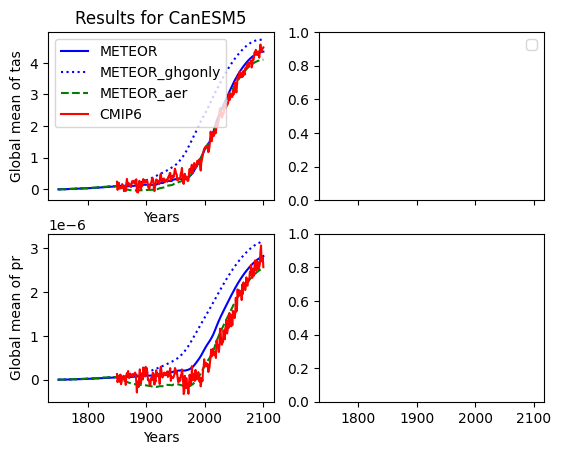

In [28]:
# NBVAL_IGNORE_OUTPUT
fig, axs = plt.subplots(nrows=len(flds), ncols=2, sharex=True)

for i, model in enumerate(models):
    for j, fld in enumerate(flds):
        zero_val = np.mean(prpatt.global_mean(data_pi[i][fld]).values)
        print(zero_val)
        hist_time = prpatt.global_mean(data_hist[i][fld]).values[0]
        #print(f"Variable: {fld} and model {model}: {hist_time}")
        axs[j,i].plot(years_total, prpatt.global_mean(pattern_ssp[i][fld]).values, color="blue", label="METEOR")
        axs[j,i].plot(years_total, prpatt.global_mean(pattern_ghg[i][fld]).values, color="blue", label="METEOR_ghgonly",linestyle=':')
        axs[j,i].plot(years_total, prpatt.global_mean(pattern_aer[i][fld]).values, color="green", label="METEOR_aer",linestyle='--')

        print(model)
        axs[j,i].plot(years_hist[:len(hist_time)], hist_time - zero_val, color="red", label="CMIP6")
        axs[j,i].plot(years_ssp, prpatt.global_mean(data_ssp[i][fld]).values[0] - zero_val, color="red")
        #axs[j,i].set_xlim(left=1850, right=2100)
        axs[j,i].set_xlabel("Years")
        if j == 0:
            axs[j,i].set_title(f"Results for {model}")
        if i == 0:
            axs[j,i].set_ylabel(f"Global mean of {fld}")
        axs[i,j].legend()
    #print(model_basic_pattern.exp_forc_dict)

The plots above don't exibit the best fits imaginable the the approach is both a bit crude, and relies on getting not only forcing but temperature from the scm which fits badly with the current architecture, hence we proceed to try a new approach

## Patterns from timescale optimization and pattern inversion ##

In [29]:
#aerosol forcing from cicero scm
f_aer=out_aer.results['forcing']['SO4_DIR']+out_aer.results['forcing']['SO4_IND']
fcg_aer=f_aer.to_xarray()
fcg_aer=fcg_aer.rename({'index':'time'})
fcg_aer['time']=pd.date_range('1750-01-01', periods=fcg_aer['time'].shape[0],freq='YS')

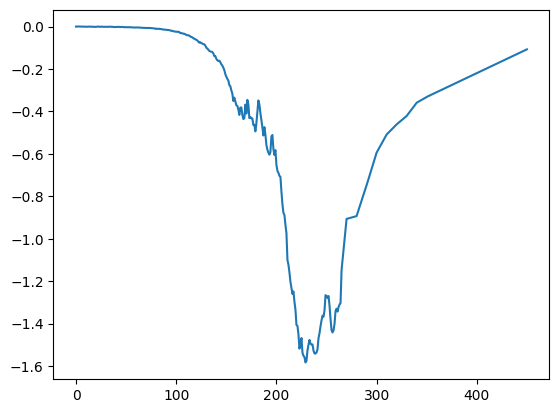

In [30]:
# NBVAL_IGNORE_OUTPUT
plt.plot(fcg_aer)

In [31]:
#make 2 guess timeseries - decay of 10 year and 80 years
decay=prpatt.expotas(np.arange(0,500),1,5)
decay100=prpatt.expotas(np.arange(0,500),1,40)


convolve aerosol forcing difference timeseries (from ciceroscm) with guess exponential decays

In [32]:
# Make matrix of exponential decays
# This is equivalent to make_amat in prpatt but not using a lmfit.parameter.Parameters to run

def make_pmat(nt,tauvec):
    out=np.zeros((len(tauvec),nt))
    for i,t in enumerate(tauvec):
        out[i,:]=prpatt.expotas(np.arange(0,nt),1,t)
    return out

In [33]:
def make_pmat_prpatt(nt, tauvec):
    return prpatt.make_pmat(tauvec, nt)


def proj_gm_prpatt(tauvec,gmanom,fcg_aer):
    #pmat=make_pmat_prpatt(500, tauvec)
    #timvec=np.apply_along_axis(lambda m: np.convolve(m, fcg_aer.diff('time'), mode='full'), axis=1, arr=pmat)[:,100:len(fcg_aer)+100]
    #projvec=np.dot(np.dot(gmanom[0,:],pinv(timvec[:,:len(gmanom['time'])])),timvec[:,:len(gmanom['time'])])
    #return projvec
    return prpatt.proj_gm(tauvec, gmanom, fcg_aer)
#Calculate root mean square error between projection of global mean time series as described above and global mean timeseries
def rmse_gm_prpatt(tauvec,gmanom,fcg_aer):
    #projvec=proj_gm_prpatt(tauvec,gmanom,fcg_aer)
    #projvec = prpatt.proj_gm(tauvec,gmanom, fcg_aer)
    #err=projvec-gmanom.values[0,:]
    #return np.sum(err**2)
    return prpatt.rmse_gm(tauvec, gmanom, fcg_aer)

In [34]:
# Make projection of the global mean anomaly onto timevectors of the exponential responses convolved with the
# derivative of the aerosol forcing timeseries
# Leveraging the make_pmat to make a matix of exponential responses for the tauvec and convolving that with the
# derivative of the aerosol forcing, we the get a timevector for the forcing decay (T)
# We the project that onto the global mean anomaly of the time series (G) as T^-1 G T

def proj_gm(tauvec,gmanom,fcg_aer):
    pmat=make_pmat(500, tauvec)
    timediff = round(pd.Timedelta(gmanom['time'][0].values-fcg_aer['time'][0].values)/pd.Timedelta('365.2425 days'))
    print(np.apply_along_axis(lambda m: np.convolve(m, fcg_aer.diff('time'), mode='full'), axis=1, arr=pmat).shape)
    timvec=np.apply_along_axis(lambda m: np.convolve(m, fcg_aer.diff('time'), mode='full'), axis=1, arr=pmat)[:,timediff:len(fcg_aer)+timediff]
    projvec=np.dot(np.dot(gmanom[0,:],pinv(timvec[:,:len(gmanom['time'])])),timvec[:,:len(gmanom['time'])])
    return projvec

In [35]:
#Calculate root mean square error between projection of global mean time series as described above and global mean timeseries
def rmse_gm(tauvec,gmanom,fcg_aer):
    projvec=proj_gm(tauvec,gmanom,fcg_aer)
    err=projvec-gmanom[0,:]
    return np.sum(err**2)

In [36]:
from scipy.optimize import minimize

Demonstrate the time constant optimization for global mean values

In [37]:
cdata_ipsl_tas=xr.concat([data_hist[0]['tas'],data_ssp[0]['tas']],'year').rename({'year':'time'})-data_pi[0]['tas'].mean('year')
#create anomaly map - complete data minus GHG only reconsruction
aerdata_demo=cdata_ipsl_tas-pattern_ghg[0]['tas']

gmanom=prpatt.global_mean(aerdata_demo)


(451,)
(1, 251)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
(2, 750)
[ 1.74212726 27.99631443]
(2, 949)
100
(2, 451)
251
(1, 251)
100
(2, 451)
251
(1, 251)
100
(2, 451)
251
(1, 251)
100
(2, 451)
251
(1, 251)
100
(2, 451)
251
(1, 251)
100
(2, 451)
251
(1, 251)
100
(2, 451)
251
(1, 251)
100
(2, 451)
251
(1, 251)
100
(2, 451)
251
(1, 251)
100
(2, 451)
251
(1, 251)
100
(2, 451)
251
(1, 251)
100
(2, 451)
251
(1, 251)
100
(2, 451)
251
(1, 251)
100
(2, 451)
251
(1, 251)
100
(2, 451)
251
(1, 251)
100
(2, 451)
251
(1

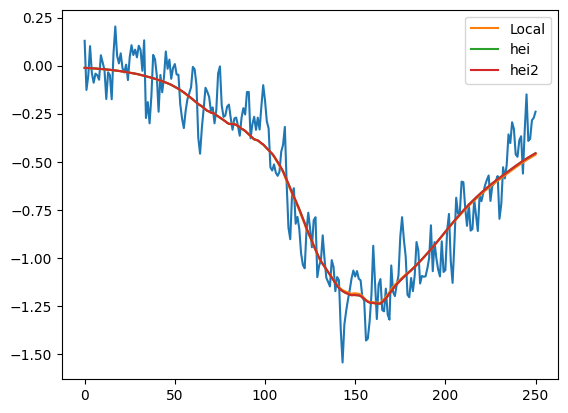

In [38]:
# NBVAL_IGNORE_OUTPUT
print(fcg_aer.shape)
print(gmanom.shape)
opt=minimize(rmse_gm,[5,50],args=(gmanom,fcg_aer[100:352]),bounds=((1, 10), (10, 100)))
print(opt.x)
plt.plot(gmanom[0,:])
plt.plot(proj_gm(opt.x,gmanom,fcg_aer), label="Local")

opt2=minimize(rmse_gm_prpatt,[5,50],args=(gmanom,fcg_aer),bounds=((1, 10), (10, 100)))
print(opt2.x)
plt.plot(proj_gm(opt2.x,gmanom, fcg_aer), label="hei")
plt.plot(proj_gm_prpatt(opt2.x, gmanom, fcg_aer)[0], label="hei2")
plt.legend()
plt.show()

Put that all together for all fields and models:

In [39]:
cdata_all=len(models)*[None]
aerdata=len(models)*[None]
apat=len(models)*[None]
aerrecon=len(models)*[None]
allrecon=len(models)*[None]
timcon=len(models)*[None]

for i, model in enumerate(models):
    cdata_all[i]={}
    aerdata[i]={}
    apat[i]={}
    aerrecon[i]={}
    allrecon[i]={}
    timcon[i]={}
    
    for j, fld in enumerate(flds):
        #create complete data, relative to PICTRL
        cdata_all[i][fld]=xr.concat([data_hist[i][fld],data_ssp[i][fld]],'year').rename({'year':'time'})-data_pi[i][fld].mean('year')
        #create anomaly map - complete data minus GHG only reconsruction
        aerdata[i][fld]=cdata_all[i][fld]-pattern_ghg[i][fld]
        #get glboal mean of aerosol anomaly for optimization
        gmanom=prpatt.global_mean(aerdata[i][fld])
        #perform optimization, minimising residual of projection
        opt=minimize(rmse_gm,[5,50],args=(gmanom,fcg_aer),bounds=((1, 10), (10, 100)))
        timcon[i][fld]=opt.x
        print(fld)
        print(f"gmanom mean: {gmanom.mean().values}, min: {gmanom.min().values} and max: {gmanom.max().values}")
        print(f"fcg_aer mean: {fcg_aer.mean().values}, min: {fcg_aer.min().values} and max: {fcg_aer.max().values}")
        print(fcg_aer.shape)
        print(opt.x)
        #make exponential decay timeseries with the optimized time constants
        pmat=prpatt.make_pmat(timcon[i][fld], 500)
        #convolve the aerosol forcing difference timeseries with the timeseries
        timvec=np.apply_along_axis(lambda m: np.convolve(m, fcg_aer.diff('time'), mode='full'), axis=1, arr=pmat)[:,100:len(fcg_aer)+100]
        nt=len(aerdata[i][fld].time)
        #invert time convolution of the aerosol-pulse response matrix
        piv=pinv(timvec[:,:nt]) 
        #project the time inverse metrix onto the aerosol anomaly map, and convert to xarray to get the spatial patterns associated with each decay mode
        tmp=np.tensordot(piv, aerdata[i][fld][0,:,:,:], (0,0))
        apat[i][fld]=xr.DataArray(data=tmp,dims=["mode","lat","lon"],coords=dict(mode=[0,1],lat=aerdata[i][fld].lat,lon=aerdata[i][fld].lon))
        if fld == "tas":
            print("Now printing v equivalent")
            print(apat[i][fld])
        #get product of the spatial patterns and the pulse response curves to reconstruct the aerosol response
        tmp=np.tensordot(apat[i][fld],timvec[:,:nt],(0,0))
        aerrecon[i][fld]=xr.DataArray(data=tmp,dims=["lat","lon","time"],coords=dict(time=aerdata[i][fld].time,lat=aerdata[i][fld].lat,lon=aerdata[i][fld].lon))
        #add the aerosol and ghg responses to produce the complete gridded emualted response
        allrecon[i][fld]=aerrecon[i][fld]+pattern_ghg[i][fld]

(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
(2, 949)
tas
gmanom mean: -0.5659439505128555, min: -1.5450049472133052 and max: 0.20384570168143906
fcg_aer mean: -0.4084054381606885, min: -1.5835204277005877 and max: 0.0005014171891780143
(451,)
[ 1.93862109 26.43196192]
Now printing v equivalent
<xarray.DataArray (mode: 2, lat: 64, lon: 128)> Size: 131kB
array([[[-0.91755793, -0.92492793, -0.92866019, ..., -0.88895571,
         -0.89859684, -0.9069205 ],
        [-0.99313106, -0.9928

In [40]:
allrecon_from_implementation=len(models)*[None]
patterns_full = len(models)*[None]
patterns_GHG = len(models)*[None]

for i, model in enumerate(models):
    allrecon_from_implementation[i]={}
    training_data_here = {
        "base": data_getter.make_meteor_training_data("base", model),
        "co2x4": data_getter.make_meteor_training_data("co2x4", model),
        "sulxanom": data_getter.make_meteor_training_data_composite(
            ["historical", "ssp245"], model
        ),
    }
    patterns_full[i] = MeteorPatternScaling(
        f"{model}_anomsulf",
        {"tas": 2, "pr": 2},
        lambda key: training_data_here[key],
        from_file=False,
        exp_list=["base", "co2x4", "sulxanom"],
    )
    print("Now printing v!!!:")
    print(patterns_full[i].pattern_dict["sulxanom"]["tas"]["pattern_full"]["v"])
    allrecon_from_implementation[i] = patterns_full[i].predict_from_combined_experiment(em_data, conc_data, ["pr", "tas"])

86
86
range(165, 251)


Parameter nystart not in pamset. Using default value 1750
Parameter nyend not in pamset. Using default value 2100
Parameter emstart not in pamset. Using default value 1850
Parameter conc_run is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter qbmb not in pamset. Using default value 0.0
Parameter qo3 not in pamset. Using default value 0.5
Parameter qdirso2 not in pamset. Using default value -0.36
Parameter qindso2 not in pamset. Using default value -0.97
Parameter qbc not in pamset. Using default value 0.16
Parameter qoc not in pamset. Using default value -0.08
Parameter qh2o_ch4 not in pamset. Using default value 0.091915
Parameter ref_yr not in pamset. Using default value 2010
Parameter beta_f not in pamset. Using default value 0.287
Parameter lifetime_mode is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter lifetime_mode is not used. Please check if yo

86
86
range(165, 251)
11
12
113
114
115
22
141
123
142
11
12
113
114
115
22
141
123
142
Parameters([('t0', <Parameter 't0', value=0.02635348496269896, bounds=[0:100.0]>), ('s0', <Parameter 's0', value=0.3232304921603683, bounds=[-inf:inf]>), ('t1', <Parameter 't1', value=3.687427419493683, bounds=[0:1000.0]>), ('s1', <Parameter 's1', value=-0.33206717172357375, bounds=[-inf:inf]>)])
Parameters([('t0', <Parameter 't0', value=99.9999999975683 +/- 1.23e+03, bounds=[0:100.0]>), ('s0', <Parameter 's0', value=6.09977879607861e-07 +/- 0.00016, bounds=[-inf:inf]>), ('t1', <Parameter 't1', value=999.5393163676133 +/- 8.05e+05, bounds=[0:1000.0]>), ('s1', <Parameter 's1', value=-4.647801352864957e-06 +/- 0.00278, bounds=[-inf:inf]>)])
Parameters([('t0', <Parameter 't0', value=1.2796126830953103 +/- 0.346, bounds=[0:100.0]>), ('s0', <Parameter 's0', value=3.1850164839660646 +/- 0.324, bounds=[-inf:inf]>), ('t1', <Parameter 't1', value=26.103846140131893 +/- 4.27, bounds=[0:1000.0]>), ('s1', <Para

Parameter nystart not in pamset. Using default value 1750
Parameter nyend not in pamset. Using default value 2100
Parameter emstart not in pamset. Using default value 1850
Parameter gaspam_data is not used. Please check if you have a typo
Parameter concentrations_data is not used. Please check if you have a typo
Parameter emissions_data is not used. Please check if you have a typo
Parameter nat_ch4_data is not used. Please check if you have a typo
Parameter nat_n2o_data is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo


Parameters([('t0', <Parameter 't0', value=99.99999990122397 +/- 1.63e+04, bounds=[0:100.0]>), ('s0', <Parameter 's0', value=-0.5822719038361511 +/- 207, bounds=[-inf:inf]>), ('t1', <Parameter 't1', value=999.963699518171 +/- 5.66e+05, bounds=[0:1000.0]>), ('s1', <Parameter 's1', value=8.40322326655873 +/- 3.62e+03, bounds=[-inf:inf]>)])
Parameters([('t0', <Parameter 't0', value=99.94600380588416 +/- 3.18e+04, bounds=[0:100.0]>), ('s0', <Parameter 's0', value=-4.2981251914603027e-07 +/- 0.000476, bounds=[-inf:inf]>), ('t1', <Parameter 't1', value=317.8481060830198 +/- 2.1e+05, bounds=[0:1000.0]>), ('s1', <Parameter 's1', value=1.5368445839189112e-06 +/- 6.7e-05, bounds=[-inf:inf]>)])


Parameter gaspam_data is not used. Please check if you have a typo
Parameter concentrations_data is not used. Please check if you have a typo
Parameter emissions_data is not used. Please check if you have a typo
Parameter nat_ch4_data is not used. Please check if you have a typo
Parameter nat_n2o_data is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter qbmb not in pamset. Using default value 0.0
Parameter qo3 not in pamset. Using default value 0.5
Parameter qdirso2 not in pamset. Using default value -0.36
Parameter qindso2 not in pamset. Using default value -0.97
Parameter qbc not in pamset. Using default value 0.16
Parameter qoc not in pamset. Using default value -0.08
Parameter qh2o_ch4 not in pamset. Using default value 0.091915
Parameter ref_yr not in pamset. Using default value 2010
Parameter beta_f not in pamset. Using default value 0.287


11
12
113
114
115
22
141
123
142
I should be here
BC
BMB_AEROS_BC
{'SO4_IND': 'SO2', 'SO4_DIR': 'SO2', 'BMB_AEROS_BC': 'SO2', 'BMB_AEROS_OC': 'OC', 'BC': 'SO2'}
OC
BMB_AEROS_OC
{'SO4_IND': 'SO2', 'SO4_DIR': 'SO2', 'BMB_AEROS_BC': 'SO2', 'BMB_AEROS_OC': 'SO2', 'BC': 'SO2', 'OC': 'SO2'}
base
co2x4
sulxanom
<xarray.DataArray ()> Size: 8B
array(1.44232722)
<xarray.DataArray ()> Size: 8B
array(8.94198024e-07)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,

Parameter nystart must be a number. Using default value 1750
Parameter emstart must be a number. Using default value 1850
Parameter gaspam_data is not used. Please check if you have a typo
Parameter concentrations_data is not used. Please check if you have a typo
Parameter emissions_data is not used. Please check if you have a typo
Parameter nat_ch4_data is not used. Please check if you have a typo
Parameter nat_n2o_data is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter nystart must be a number. Using default value 1750
Parameter emstart must be a number. Using default value 1850
Parameter gaspam_data is not used. Please check if you have a typo
Parameter concentrations_data is not used. Please check if you have a typo
Parameter emissions_data is not used. Please check if you have a typo
Parameter nat_ch4_data is not used. Please check if you have a typo
Parameter nat_n2o_data is not used. Please check if you have a t

0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
0
(2, 251)
251
(251,)
Parameters([('t0', <Parameter 't0', value=5.0, bounds=[1:10]>), ('s0', <Parameter 's0', value=1, bounds=[0.9:1.1]>), ('t1', <Parameter 't1', value=50.0, bounds=[10:100]>), ('s1', <Parameter 's1', value=1, bounds=[0.9:1.1]>)])
dict_keys(['base', 'co2x4', 'sulxanom'])
Parameters([('t0', <Parameter 't0', value=8.735112105768483 +/- 1.23, bounds=[0:100.0]>), ('s0', <Parameter 's0', value=2.8241706533311227e-06 +/- 3.77e-07, bounds=[-inf:inf]>), ('t1', <Parameter 't1', value=78.88618942512693 +/- 41, bounds=[0:1000.0]>), ('s1', <Parameter 's1', value=2.919598569944732e-06 +/- 3.52e-07, bounds=[-inf:inf]>)])
Now printing v!!!:
<xarray.DataArray (mode: 2, lat: 64, lon: 128)> Size: 131kB
array([[[-0.80976569, -0.81657816, -0.81996404, ..., -0.78347283,
         -0.79225116, -0.79982206],
        [-0.87842913, -0.87790648, -0.86650496, ..., -0.85022502,
         -0.86082282, -0.8724857 ],
        [-0.83158189, -0.79584826, -0.761

Plot global means of reconstructed spatial response to aerosol forcing from 2 patterns and 2 convolved coefficient timeseries

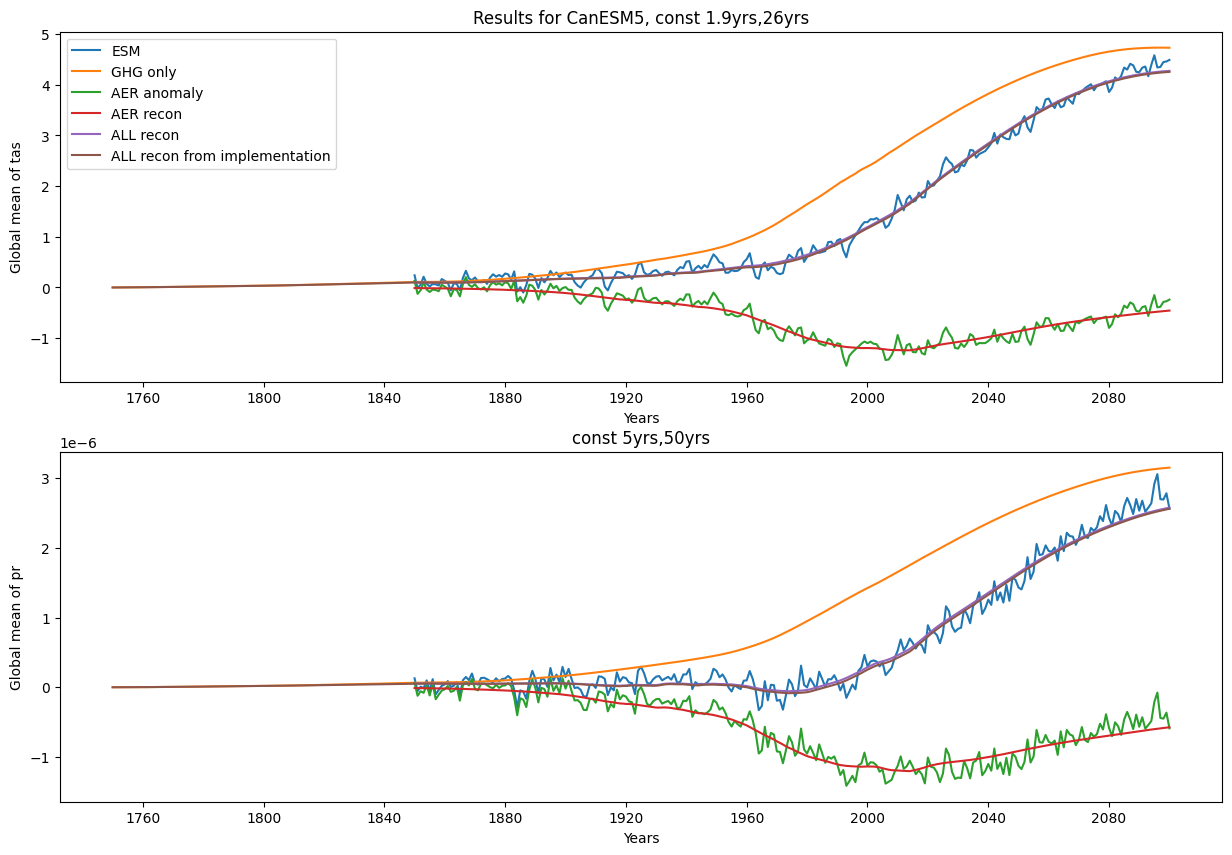

In [41]:
# NBVAL_IGNORE_OUTPUT
fig, axs = plt.subplots(nrows=len(flds), ncols=len(models), figsize=[15,10])

for i, model in enumerate(models):
    for j, fld in enumerate(flds):
        prpatt.global_mean(cdata_all[i][fld]).plot(label="ESM",ax=axs[j])
        prpatt.global_mean(pattern_ghg[i][fld]).plot(label="GHG only",ax=axs[j])
        prpatt.global_mean(aerdata[i][fld]).plot(label="AER anomaly",ax=axs[j])
        prpatt.global_mean(aerrecon[i][fld]).plot(label="AER recon",ax=axs[j])
        prpatt.global_mean(allrecon[i][fld]).plot(label="ALL recon",ax=axs[j])
        prpatt.global_mean(allrecon_from_implementation[i][fld]).plot(label="ALL recon from implementation",ax=axs[j])

        
        
        axs[j].set_xlabel("Years")
        if j == 0:
            axs[j].set_title(f"Results for {model}, const "+'%.2g' % (timcon[i][fld][0])+'yrs,'+'%.2g' % (timcon[i][fld][1])+'yrs')
        else:
            axs[j].set_title(f"const "+'%.2g' % (timcon[i][fld][0])+'yrs,'+'%.2g' % (timcon[i][fld][1])+'yrs')

        if i == 0:
            axs[j].set_ylabel(f"Global mean of {fld}")
        axs[i].legend()
    #print(model_basic_pattern.exp_forc_dict)